## Imports

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

## Configurações

In [2]:
PROCESSED_DIR = Path("../../data/interim")
RESULTS_DIR = Path("../../data/interim/deseq2")

FILTERED_EXPRESSION_PATH = PROCESSED_DIR / "microplastic_expression_filtered.csv"
METADATA_PATH = PROCESSED_DIR / "microplastic_metadata.csv"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.05
LFC_THRESHOLD = 1.0  # apenas para sumarização/visualização

## Carregamento dos Dados Filtrados

In [3]:
expression_df = pd.read_csv(FILTERED_EXPRESSION_PATH)
metadata_df = pd.read_csv(METADATA_PATH)

print("Matriz filtrada:", expression_df.shape)
print("Metadados:", metadata_df.shape)

display(expression_df.head())
display(metadata_df.head())

Matriz filtrada: (15989, 25)
Metadados: (24, 9)


,gene_id,CTR_1,CTR_2,CTR_3,MA1_1,MA1_2,MA1_3,MA100_1,MA100_2,MA100_3,...,MB100_3,MC1_1,MC1_2,MC1_3,MC100_1,MC100_2,MC100_3,MD1_1,MD1_2,MD1_3
0,ENSG00000000003,357,327,329,276,226,355,336,285,323,...,334,279,319,370,310,358,398,276,365,336
1,ENSG00000000419,770,453,733,605,629,716,721,700,733,...,633,533,857,680,727,974,712,655,796,969
2,ENSG00000000457,27,115,31,26,33,35,30,31,7,...,44,32,17,27,41,68,67,42,38,47
3,ENSG00000000460,37,27,7,4,5,36,29,3,0,...,19,27,45,20,12,21,33,3,27,0
4,ENSG00000001036,980,943,970,807,886,1855,1094,780,1174,...,1046,1030,1175,1234,1286,1353,1381,1076,1243,1156


,particle_type,particle_size_um,particle_size_nm,concentration_gL,is_control,treatment_status,sample_id,group,replicate
0,control,NaN,NaN,0.0,True,control,CTR_1,CTR,1
1,control,NaN,NaN,0.0,True,control,CTR_2,CTR,2
2,control,NaN,NaN,0.0,True,control,CTR_3,CTR,3
3,polystyrene,1.0,1000.0,0.1,False,treated,MA1_1,MA1,1
4,polystyrene,1.0,1000.0,0.1,False,treated,MA1_2,MA1,2


## Preparação da Matriz para DEG (Differentially Expressed Genes)

In [4]:
# A matriz carregada tem genes como linhas e amostras como colunas, mas o DESeq2 espera o contrário.
# Transpondo a matriz para ter amostras como linhas e genes como colunas.

sample_ids = metadata_df["sample_id"].tolist()
expr_sample_cols = [c for c in expression_df.columns if c != "gene_id"]

missing_in_expr = sorted(set(sample_ids) - set(expr_sample_cols))
missing_in_meta = sorted(set(expr_sample_cols) - set(sample_ids))

if missing_in_expr or missing_in_meta:
    raise ValueError(
        f"Inconsistência entre matriz e metadata.\n"
        f"Ausentes na expressão: {missing_in_expr}\n"
        f"Ausentes no metadata: {missing_in_meta}"
    )

# Reordena colunas pela ordem do metadata
expression_df = expression_df[["gene_id"] + sample_ids]

# counts: samples x genes
counts = expression_df.set_index("gene_id").T
counts.index.name = "sample_id"

# Garante inteiros
counts = counts.astype(int)

# Metadata indexado por sample_id
metadata = metadata_df.set_index("sample_id").loc[counts.index].copy()

# Fator de condição principal para os contrastes
metadata["condition"] = metadata["group"].astype(str)

print("Counts:", counts.shape)
print("Metadata:", metadata.shape)

display(counts.iloc[:5, :5])
display(metadata.head())

Counts: (24, 15989)
Metadata: (24, 9)


gene_id,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000001036
sample_id,,,,,
CTR_1,357,770,27,37,980
CTR_2,327,453,115,27,943
CTR_3,329,733,31,7,970
MA1_1,276,605,26,4,807
MA1_2,226,629,33,5,886


,particle_type,particle_size_um,particle_size_nm,concentration_gL,is_control,treatment_status,group,replicate,condition
sample_id,,,,,,,,,
CTR_1,control,NaN,NaN,0.0,True,control,CTR,1,CTR
CTR_2,control,NaN,NaN,0.0,True,control,CTR,2,CTR
CTR_3,control,NaN,NaN,0.0,True,control,CTR,3,CTR
MA1_1,polystyrene,1.0,1000.0,0.1,False,treated,MA1,1,MA1
MA1_2,polystyrene,1.0,1000.0,0.1,False,treated,MA1,2,MA1


In [5]:
# Validações finais antes do DESeq2

print("Condições disponíveis:")
print(sorted(metadata["condition"].unique()))

print("\nNúmero de amostras por condição:")
display(metadata["condition"].value_counts().sort_index())

print("\nAlgum valor ausente em counts?", counts.isna().sum().sum() > 0)
print("Algum valor negativo em counts?", (counts < 0).any().any())
print("Todos os counts são inteiros?", np.all(np.equal(np.mod(counts.to_numpy(), 1), 0)))

Condições disponíveis:
['CTR', 'MA1', 'MA100', 'MB1', 'MB100', 'MC1', 'MC100', 'MD1']

Número de amostras por condição:


condition
CTR      3
MA1      3
MA100    3
MB1      3
MB100    3
MC1      3
MC100    3
MD1      3
Name: count, dtype: int64


Algum valor ausente em counts? False
Algum valor negativo em counts? False
Todos os counts são inteiros? True


## Ajuste do Modelo DESeq2

In [6]:
dds = DeseqDataSet(
    counts=counts,
    metadata=metadata,
    design="~ condition",
    quiet=False,
)

dds.deseq2()

print("Modelo DESeq2 ajustado com sucesso.")

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 0.85 seconds.

Fitting dispersion trend curve...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 1.09 seconds.

Fitting LFCs...


Modelo DESeq2 ajustado com sucesso.


... done in 0.84 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



## Definição dos Contrastes

In [7]:
# Queremos contrastar as seguintes comparações, onde o primeiro elemento é o grupo de teste
# e o segundo é o grupo de referência (controle). O DESeq2 irá comparar o primeiro grupo contra
# o segundo, então a interpretação dos resultados será "diferença do grupo de teste em relação ao
# grupo de referência".

contrasts = [
    # Tratamento vs controle
    ("MA100", "CTR"),
    ("MB100", "CTR"),
    ("MC100", "CTR"),
    ("MA1", "CTR"),
    ("MB1", "CTR"),
    ("MC1", "CTR"),
    ("MD1", "CTR"),

    # Comparações pareadas por concentração entre 0.1 µm e 1 µm
    ("MA100", "MA1"),
    ("MB100", "MB1"),
    ("MC100", "MC1"),
]

print("Contrastes definidos:")
for tested, ref in contrasts:
    print(f"- {tested} vs {ref}")

Contrastes definidos:
- MA100 vs CTR
- MB100 vs CTR
- MC100 vs CTR
- MA1 vs CTR
- MB1 vs CTR
- MC1 vs CTR
- MD1 vs CTR
- MA100 vs MA1
- MB100 vs MB1
- MC100 vs MC1


## Execução dos Contrastes

In [8]:
## Função auxiliar para rodar contraste

def run_contrast(dds, tested_level: str, ref_level: str, alpha: float = 0.05) -> pd.DataFrame:
    """
    Executa um contraste DESeq2 e retorna um DataFrame com os resultados.
    """
    stat_res = DeseqStats(
        dds,
        contrast=["condition", tested_level, ref_level],
        alpha=alpha,
        quiet=False,
    )

    stat_res.summary()

    res = stat_res.results_df.copy().reset_index()
    res = res.rename(columns={"index": "gene_id"})
    res["contrast"] = f"{tested_level}_vs_{ref_level}"

    # Flags úteis
    res["significant"] = (~res["padj"].isna()) & (res["padj"] < alpha)
    res["direction"] = np.where(
        res["log2FoldChange"] > 0,
        f"up_in_{tested_level}",
        f"up_in_{ref_level}"
    )

    return res.sort_values(["padj", "pvalue"], na_position="last")

In [9]:
## Execução dos contrastes

all_results = {}
summary_rows = []

for tested, ref in contrasts:
    contrast_name = f"{tested}_vs_{ref}"
    print(f"\n=== Rodando contraste: {contrast_name} ===")

    res = run_contrast(dds, tested_level=tested, ref_level=ref, alpha=ALPHA)
    all_results[contrast_name] = res

    # Salva tabela individual
    output_file = RESULTS_DIR / f"deg_{contrast_name}.csv"
    res.to_csv(output_file, index=False)

    sig = res["significant"].fillna(False)
    up = sig & (res["log2FoldChange"] > 0)
    down = sig & (res["log2FoldChange"] < 0)

    summary_rows.append({
        "contrast": contrast_name,
        "n_genes_tested": res.shape[0],
        "n_significant": int(sig.sum()),
        "n_up_in_tested": int(up.sum()),
        "n_up_in_reference": int(down.sum()),
        "output_file": str(output_file),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

Running Wald tests...



=== Rodando contraste: MA100_vs_CTR ===


... done in 0.48 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition MA100 vs CTR
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                      
ENSG00000000003   315.753825       -0.227367  0.193564 -1.174632  0.240142   
ENSG00000000419   697.240745        0.020602  0.194543  0.105901  0.915661   
ENSG00000000457    37.833392       -1.405446  0.603630 -2.328323  0.019895   
ENSG00000000460    19.544796       -1.259490  1.084444 -1.161416  0.245473   
ENSG00000001036  1065.876976       -0.070932  0.156848 -0.452235  0.651100   
...                      ...             ...       ...       ...       ...   
ENSG00000293510   182.326633       -0.849047  0.334712 -2.536652  0.011192   
ENSG00000293512    25.382528       -0.154994  1.001201 -0.154808  0.876973   
ENSG00000293514    79.898153        0.336345  0.388075  0.866700  0.386106   
ENSG00000293515    31.362016       -0.194228  0.678464 -0.286276  0.774667   
ENS

... done in 0.56 seconds.

Running Wald tests...


...

Log2 fold change & Wald test p-value: condition MA100 vs MA1
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                      
ENSG00000000003   315.753825        0.065459  0.194651  0.336290  0.736652   
ENSG00000000419   697.240745        0.060380  0.194577  0.310314  0.756322   
ENSG00000000457    37.833392       -0.483276  0.612182 -0.789432  0.429859   
ENSG00000000460    19.544796       -0.403333  1.095173 -0.368283  0.712663   
ENSG00000001036  1065.876976       -0.261252  0.156535 -1.668969  0.095124   
...                      ...             ...       ...       ...       ...   
ENSG00000293510   182.326633       -0.637099  0.335391 -1.899568  0.057490   
ENSG00000293512    25.382528        0.433823  1.007522  0.430584  0.666771   
ENSG00000293514    79.898153        0.299203  0.387493  0.772149  0.440026   
ENSG00000293515    31.362016        0.112493  0.681793  0.164996  0.868947   
ENS

... done in 0.49 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition MB100 vs MB1
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                      
ENSG00000000003   315.753825       -0.106964  0.194141 -0.550962  0.581659   
ENSG00000000419   697.240745        0.040071  0.194679  0.205831  0.836923   
ENSG00000000457    37.833392        0.273832  0.604649  0.452878  0.650637   
ENSG00000000460    19.544796       -1.189305  1.071008 -1.110453  0.266804   
ENSG00000001036  1065.876976        0.049489  0.156946  0.315325  0.752515   
...                      ...             ...       ...       ...       ...   
ENSG00000293510   182.326633       -0.161273  0.333093 -0.484168  0.628267   
ENSG00000293512    25.382528       -0.326677  0.996805 -0.327724  0.743120   
ENSG00000293514    79.898153        0.061176  0.384303  0.159188  0.873521   
ENSG00000293515    31.362016       -0.384975  0.683423 -0.563304  0.573228   
ENS

... done in 0.49 seconds.



,contrast,n_genes_tested,n_significant,n_up_in_tested,n_up_in_reference,output_file
0,MA100_vs_CTR,15989,1355,638,717,../../data/interim/deseq2/deg_MA100_vs_CTR.csv
1,MB100_vs_CTR,15989,25,6,19,../../data/interim/deseq2/deg_MB100_vs_CTR.csv
2,MC100_vs_CTR,15989,0,0,0,../../data/interim/deseq2/deg_MC100_vs_CTR.csv
3,MA1_vs_CTR,15989,257,105,152,../../data/interim/deseq2/deg_MA1_vs_CTR.csv
4,MB1_vs_CTR,15989,667,338,329,../../data/interim/deseq2/deg_MB1_vs_CTR.csv
5,MC1_vs_CTR,15989,1466,709,757,../../data/interim/deseq2/deg_MC1_vs_CTR.csv
6,MD1_vs_CTR,15989,1215,563,652,../../data/interim/deseq2/deg_MD1_vs_CTR.csv
7,MA100_vs_MA1,15989,157,105,52,../../data/interim/deseq2/deg_MA100_vs_MA1.csv
8,MB100_vs_MB1,15989,16,8,8,../../data/interim/deseq2/deg_MB100_vs_MB1.csv
9,MC100_vs_MC1,15989,1946,847,1099,../../data/interim/deseq2/deg_MC100_vs_MC1.csv


## Visualizações

In [10]:
## Função de volcano plot

def plot_volcano(
    results_df: pd.DataFrame,
    title: str,
    alpha: float = 0.05,
    lfc_threshold: float = 1.0,
    max_points: int | None = None,
):
    df = results_df.copy()

    # Remove linhas sem informação estatística
    df = df.dropna(subset=["log2FoldChange", "pvalue"])

    if max_points is not None and df.shape[0] > max_points:
        df = df.sample(max_points, random_state=42)

    df["neglog10_padj"] = -np.log10(df["padj"].fillna(1.0).clip(lower=1e-300))

    sig_up = (df["padj"] < alpha) & (df["log2FoldChange"] >= lfc_threshold)
    sig_down = (df["padj"] < alpha) & (df["log2FoldChange"] <= -lfc_threshold)
    non_sig = ~(sig_up | sig_down)

    plt.figure(figsize=(8, 6))
    plt.scatter(df.loc[non_sig, "log2FoldChange"], df.loc[non_sig, "neglog10_padj"], s=10, alpha=0.5, label="não significativo")
    plt.scatter(df.loc[sig_up, "log2FoldChange"], df.loc[sig_up, "neglog10_padj"], s=12, alpha=0.8, label="up")
    plt.scatter(df.loc[sig_down, "log2FoldChange"], df.loc[sig_down, "neglog10_padj"], s=12, alpha=0.8, label="down")

    plt.axvline(lfc_threshold, linestyle="--")
    plt.axvline(-lfc_threshold, linestyle="--")
    plt.axhline(-np.log10(alpha), linestyle="--")

    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10(padj)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

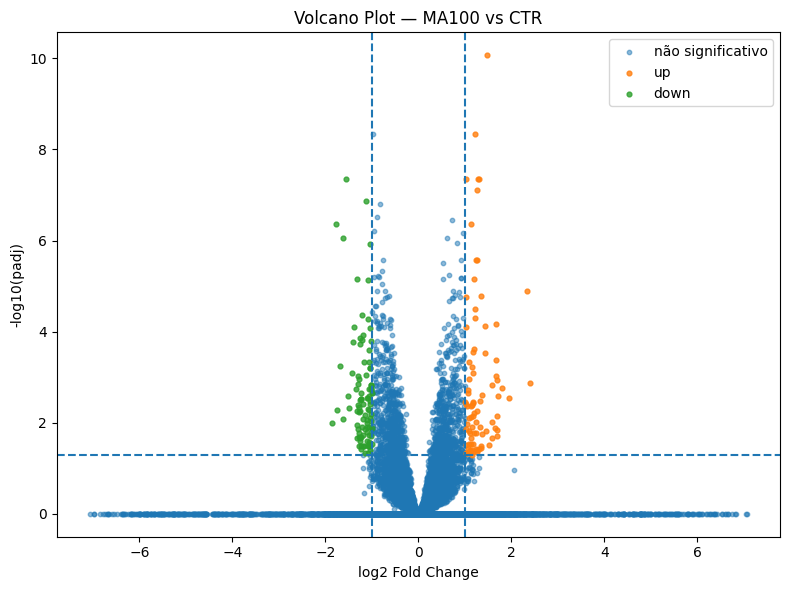

In [11]:
plot_volcano(
    all_results["MA100_vs_CTR"],
    title="Volcano Plot — MA100 vs CTR",
    alpha=ALPHA,
    lfc_threshold=LFC_THRESHOLD,
)

## Salvamento dos Resultados

In [12]:
all_results_df = pd.concat(all_results.values(), axis=0, ignore_index=True)

all_results_path = RESULTS_DIR / "deg_all_contrasts.csv"
all_results_df.to_csv(all_results_path, index=False)

print(f"Tabela consolidada salva em: {all_results_path}")
print("Dimensões:", all_results_df.shape)

Tabela consolidada salva em: ../../data/interim/deseq2/deg_all_contrasts.csv
Dimensões: (159890, 10)
